# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [2]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

### Double check some datatypes, and for nulls and duplicates:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [7]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [8]:
df.Segment.unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [9]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [10]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [11]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [12]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [13]:
query2 = """ 
SELECT c.customer_name,sum(od.sales) as total_sales
FROM customers c 
JOIN orders o ON o.customer_id = c.customer_id
JOIN order_details od ON od.order_id = o.order_id
GROUP BY c.customer_name
ORDER BY total_sales DESC
LIMIT 10;

"""
result2 = pd.read_sql(query2, conn)
result2

,customer_name,total_sales
0,Ken Lonsdale,155927.519
1,Sanjit Engle,134303.818
2,Clay Ludtke,130566.552
3,Adrian Barton,130262.139
4,Sanjit Chand,127281.006
5,Sean Miller,125215.250
6,Edward Hooks,123730.560
7,Greg Tran,118201.200
8,Seth Vernon,114709.500
9,John Lee,107799.153


### Which product categories and subcategories are the most profitable overall?

In [14]:
query3 = """ 
SELECT p.category, p.subcategory, sum(od.sales) as total_sales
FROM products p
JOIN order_details od ON od.product_id = p.product_id
GROUP BY p.category, p.subcategory
ORDER BY total_sales desc;
 """
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,total_sales
0,Technology,Phones,356702.3540
1,Furniture,Chairs,330891.1270
2,Office Supplies,Storage,224958.5600
3,Office Supplies,Binders,211231.7210
4,Furniture,Tables,206965.5320
5,Technology,Machines,194442.8720
6,Technology,Accessories,192960.0260
7,Technology,Copiers,149528.0300
8,Furniture,Bookcases,127801.6393
9,Office Supplies,Appliances,109543.0130


### What is the average discount given per category?

In [15]:
query4 = """ 
SELECT p.category as category, (CAST(avg(od.discount) * 100 AS VARCHAR) + ' %') as avg_discount_percent
FROM products p
JOIN order_details od ON od.product_id = p.product_id
GROUP BY p.category;

 """
result4 = pd.read_sql(query4, conn)
result4

#idk why the percent sign isnt showing
#was just trying to make it look better
#not going to fuss with it

,category,avg_discount_percent
0,Furniture,17.251354
1,Office Supplies,15.699968
2,Technology,13.297045


### Which states or regions contribute the most to total sales?

In [16]:
query5 = """ 
SELECT c.state, sum(od.sales) as total_sales
from customers c
JOIN orders o ON o.customer_id = c.customer_id
JOIN order_details od ON od.order_id = o.order_id
GROUP BY c.state
ORDER BY total_sales DESC;

 """
result5 = pd.read_sql(query5, conn)
result5

## is hawaii not on th list ? 
# maybe they don't ship there....


,state,total_sales
0,California,3.314838e+06
1,New York,1.859365e+06
2,Texas,1.547926e+06
3,Pennsylvania,8.861057e+05
4,Washington,8.622987e+05
5,Illinois,8.433528e+05
6,Ohio,7.077477e+05
7,Florida,6.356378e+05
8,North Carolina,4.379384e+05
9,Michigan,4.324280e+05


In [17]:
### SAME WITH REGION 


query50 = """ 
SELECT c.region as region, sum(od.sales) as total_sales
from customers c
JOIN orders o ON o.customer_id = c.customer_id
JOIN order_details od ON od.order_id = o.order_id
GROUP BY region
ORDER BY total_sales DESC;

 """
result50 = pd.read_sql(query50, conn)
result50

,region,total_sales
0,West,5.306522e+06
1,East,4.522990e+06
2,Central,3.853692e+06
3,South,2.706438e+06


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [18]:
query6 = """
SELECT count(o.order_id)
FROM orders o
WHERE o.ship_date > (o.order_date + 3)
;

"""
result6 = pd.read_sql(query6, conn)
result6

#IDK this doesnt seem right ?

,count(o.order_id)
0,5009


### Which month or year had the highest total sales?

In [19]:
query7 = """ 
SELECT strftime('%Y', o.order_date) AS order_year,
sum(od.sales) as total_sales
FROM orders o
JOIN order_details od ON od.order_id = o.order_id
GROUP BY order_year
ORDER BY order_year;


"""
result7 = pd.read_sql(query7, conn)
result7



,order_year,total_sales
0,2011,484247.4981
1,2012,470532.5090
2,2013,608473.8300
3,2014,733947.0232


In [20]:
query70 = """ 
SELECT strftime('%m', o.order_date) AS order_month,
sum(od.sales) as total_sales
FROM orders o
JOIN order_details od ON od.order_id = o.order_id
GROUP BY order_month
ORDER BY order_month;

"""
result70 = pd.read_sql(query70, conn)
result70

,order_month,total_sales
0,01,95365.9376
1,02,60172.6494
2,03,199252.9840
3,04,141851.5674
4,05,156122.2867
5,06,147082.6113
6,07,149580.8380
7,08,159589.4510
8,09,309770.0997
9,10,197115.2017


### What are the most frequently ordered products?

In [21]:
query8 = """ 
SELECT p.product_name, count(od.product_id) as total_product_sales
FROM products p
JOIN order_details od ON od.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_product_sales DESC
LIMIT 10;

 """
result8 = pd.read_sql(query8, conn)
result8

,product_name,total_product_sales
0,Staples,227
1,Avery Non-Stick Binders,20
2,Xerox 1908,19
3,Xerox 1881,19
4,Logitech P710e Mobile Speakerphone,18
5,KI Adjustable-Height Table,18
6,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,18
7,Storex Dura Pro Binders,17
8,"Executive Impressions 13"" Clairmont Wall Clock",16
9,"Eldon Image Series Desk Accessories, Burgundy",16


### Which customers placed more than 5 orders total?

In [28]:
query9 = """ 
SELECT c.customer_name, count(o.customer_id) as orders_placed
FROM customers c
JOIN orders o ON o.customer_id = c.customer_id
GROUP BY c.customer_name
HAVING orders_placed > 5
ORDER BY orders_placed DESC
;


 """
result9 = pd.read_sql(query9, conn)
result9

#if i add  WHERE orders_placed > 5
# operational error: misuse of aggregate: count()

,customer_name,orders_placed
0,Emily Phan,289
1,Zuschuss Carroll,169
2,Sally Hughsby,169
3,Joel Eaton,169
4,Erin Ashbrook,169
...,...,...
742,Bart Folk,9
743,Barry Weirich,9
744,Astrea Jones,9
745,Alyssa Crouse,9


### What’s the profit margin (profit ÷ sales) by category or segment?

In [ ]:
query10 = """ 

SELECT c.customer_category as segment, (od.profit / od.sales) as profit_margin
FROM customers c
JOIN orders o ON o.customer_id = c.customer_id
JOIN order_details od ON od.order_id = o.order_id
GROUP BY segment
ORDER BY profit_margin DESC;


 """
result10 = pd.read_sql(query10, conn)
result10

,segment,profit_margin
0,Corporate,0.470
1,Home Office,0.375
2,Consumer,0.160


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

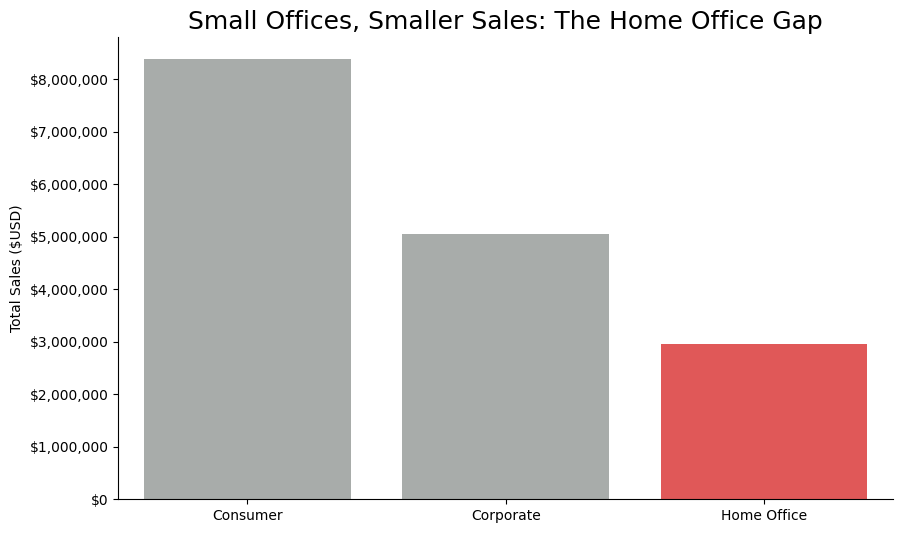

In [ ]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


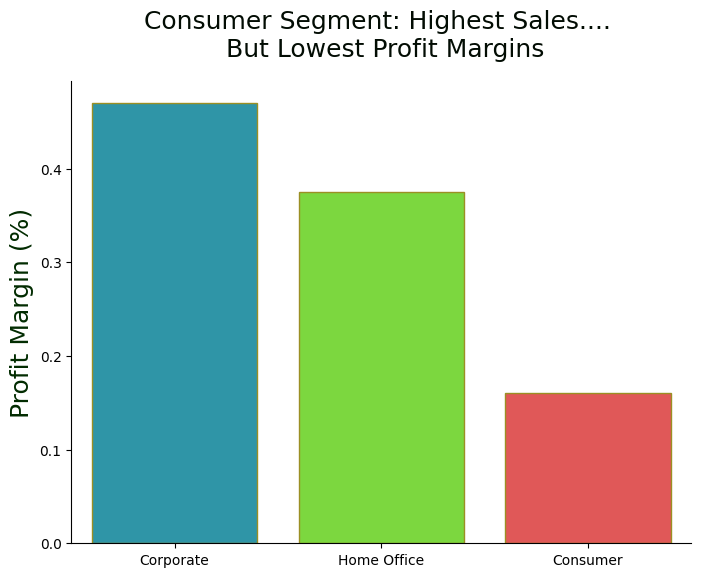

In [ ]:



plt.figure(figsize=(8,6))
colors = ["#1BA3BB", "#77f125", "#f74141" ]
sns.barplot(result10, x='segment', y='profit_margin', palette=colors, hue='segment', edgecolor= "#9B8F24", legend=False)
plt.ylabel("Profit Margin (%)", fontsize= 18, color=  "#012B00")
plt.title("Consumer Segment: Highest Sales.... \n But Lowest Profit Margins", fontsize= 18, color=  "#020C03", pad=18)
plt.xlabel(None)

plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()

sns.despine()
plt.show()



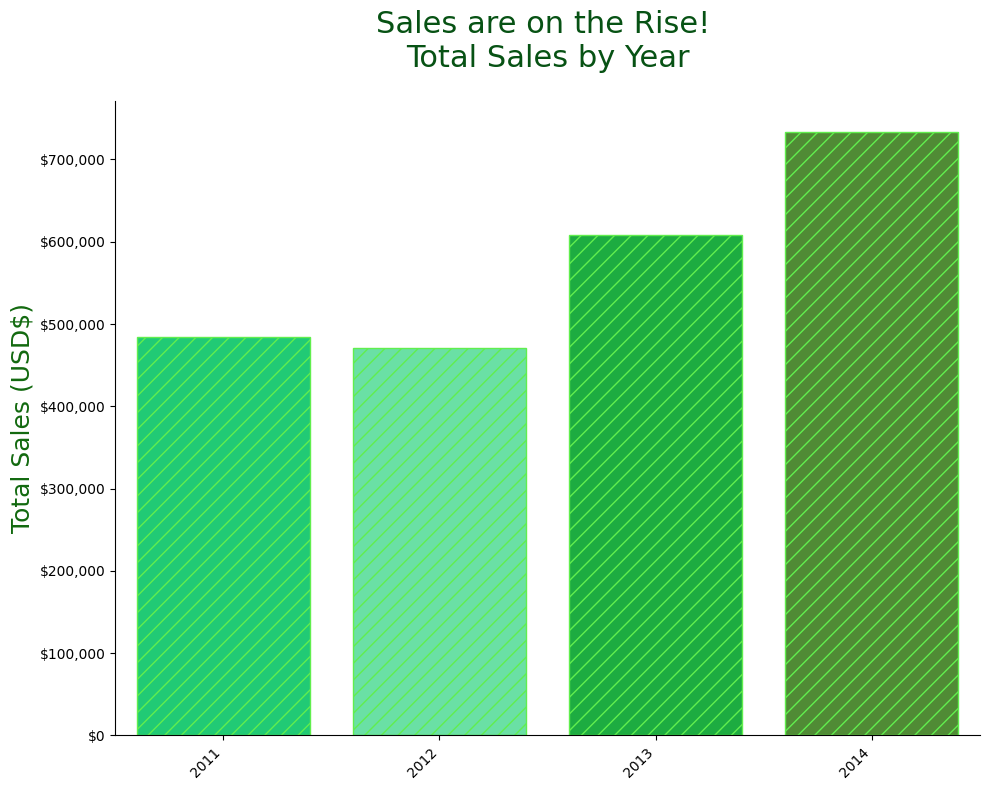

In [ ]:


plt.figure(figsize=(10,8))
colors = ["#05e675", "#57f3a5", "#05c435", "#4B9927" ]
sns.barplot(result7, x='order_year', y='total_sales', palette= colors, hue = "order_year", edgecolor= "#61ee4e", hatch = "//", legend=False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel(None)
plt.ylabel("Total Sales (USD$)", fontsize= 18, color=  "#12690F")
plt.title("Sales are on the Rise! \nTotal Sales by Year", fontsize= 22, color=  "#075214", pad=25)
plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style='plain', axis='y')
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

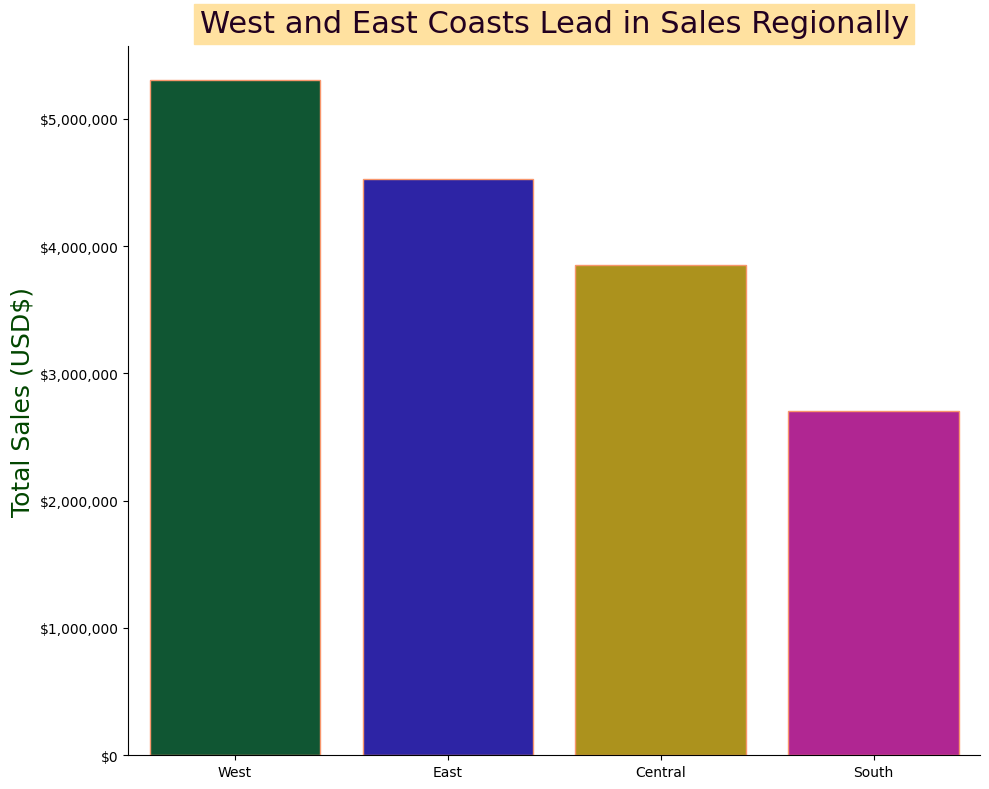

In [ ]:

plt.figure(figsize=(10,8))
colors = ["#056133", "#1A0EBB", "#c4a105", "#C70F9F" ]
sns.barplot(result50, x='region', y='total_sales', palette= colors, hue= 'region', edgecolor= "#F8966C",legend=False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel(None)
plt.ylabel("Total Sales (USD$)", fontsize= 18, color=  "#024600")
plt.title("West and East Coasts Lead in Sales Regionally", fontsize= 22, color=  "#220120", backgroundcolor= "#FFE1A0", pad=10)


plt.ticklabel_format(style='plain', axis='y')
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

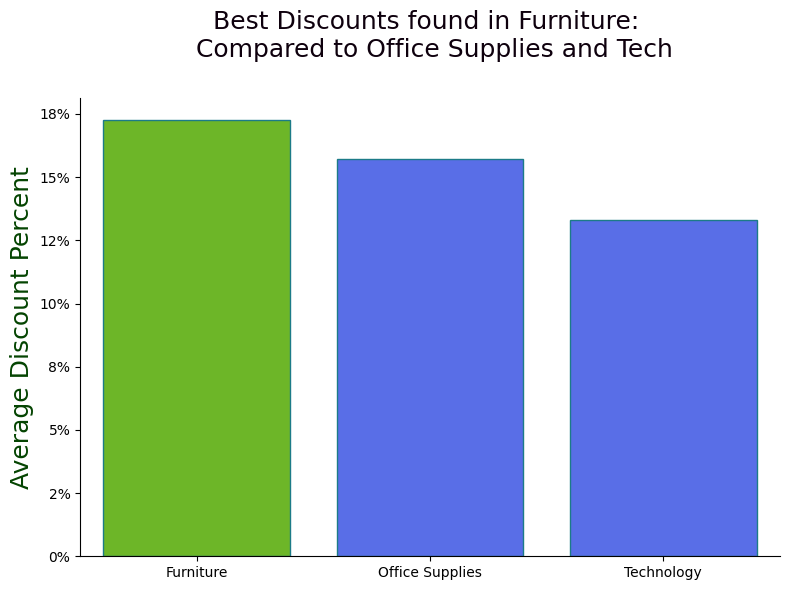

In [ ]:

plt.figure(figsize=(8,6))
colors = ["#6CCE10", "#415eff", "#415eff" ]
sns.barplot(result4, x='category', y='avg_discount_percent', palette= colors, hue= 'category', edgecolor= "#1C7B88", legend=False)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel(None)
plt.ylabel("Average Discount Percent", fontsize= 18, color=  "#044401")
plt.title("Best Discounts found in Furniture: \n Compared to Office Supplies and Tech", fontsize= 18, color=  "#0E000D", pad=30)


plt.ticklabel_format(style='plain', axis='y')
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}%'))

plt.tight_layout()
plt.show()

